In [22]:
import pandas as pd
import numpy as np
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Latest Checkpoint

In [23]:
# Find the most recent checkpoint file
checkpoint_dir = Path('checkpoints')
checkpoint_files = sorted(checkpoint_dir.glob('ml_strategies_checkpoint_*.pkl'))

if not checkpoint_files:
    print("No checkpoint files found. Please run main.py first to train models.")
else:
    latest_checkpoint = checkpoint_files[-1]
    print(f"Loading checkpoint: {latest_checkpoint.name}")
    
    with open(latest_checkpoint, 'rb') as f:
        checkpoint_data = pickle.load(f)
    
    strategies = checkpoint_data.get('strategies', [])
    timestamp = checkpoint_data.get('timestamp')
    
    print(f"Checkpoint timestamp: {timestamp}")
    print(f"Number of ML strategies: {len(strategies)}")
    print("\nStrategy names:")
    for i, strat in enumerate(strategies, 1):
        print(f"  {i}. {strat.name}")

Loading checkpoint: ml_strategies_checkpoint_20251116_105631.pkl
Checkpoint timestamp: 2025-11-16 10:56:59.717077
Number of ML strategies: 10

Strategy names:
  1. LinReg_10f
  2. ElasticNet_10f
  3. LASSO_10f
  4. XGB_10f
  5. KNN_10f
  6. DTree_10f
  7. ExtraTrees_10f
  8. RF_10f
  9. GBT_10f
  10. AdaBoost_10f


## 2. Load Best Hyperparameters

In [24]:
# Find the most recent best params file
best_params_files = sorted(checkpoint_dir.glob('ml_best_params_*.pkl'))

if best_params_files:
    latest_params = best_params_files[-1]
    print(f"Loading parameters: {latest_params.name}")
    
    with open(latest_params, 'rb') as f:
        best_params = pickle.load(f)
    
    print("\nBest Hyperparameters:")
    print("=" * 70)
    for model_name, params in best_params.items():
        print(f"\n{model_name}:")
        for param, value in params.items():
            print(f"  {param}: {value}")
else:
    print("No best params file found.")
    best_params = {}

Loading parameters: ml_best_params_20251116_105631.pkl

Best Hyperparameters:

Elastic Net:
  alpha: 0.01
  l1_ratio: 0.9

LASSO:
  alpha: 0.01

XGBoost:
  learning_rate: 0.01
  max_depth: 5
  n_estimators: 100
  subsample: 1.0

K-Nearest Neighbor:
  n_neighbors: 10
  weights: uniform

Decision Tree:
  max_depth: 5
  min_samples_leaf: 4
  min_samples_split: 10

Extra Trees:
  max_depth: 10
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 200

Random Forest:
  max_depth: 10
  min_samples_leaf: 4
  min_samples_split: 2
  n_estimators: 100

Gradient Boosting:
  learning_rate: 0.01
  max_depth: 3
  min_samples_split: 2
  n_estimators: 100

Adaptive Boosting:
  learning_rate: 0.1
  n_estimators: 100


## 3. Extract Feature Names

Get the feature names from the trained models.

In [25]:
# Get feature names from the first strategy's data
if strategies:
    # We need to rebuild features to get feature names
    from config import *
    from data.data_loader import DataLoader
    from utils.strategy_factory import create_rule_based_strategies
    from features.feature_engineering import build_ml_features_from_strategies
    
    # Load price data
    print("Loading price data...")
    loader = DataLoader(TICKER, START_DATE, END_DATE)
    prices = loader.get_prices()
    if isinstance(prices, pd.Series):
        prices = prices.to_frame()
    
    # Calculate test start date
    train_pct = float(ML_PARAMS.get('train_test_split', 0.75))
    split_idx = int(len(prices) * train_pct)
    test_start_date = prices.index[split_idx]
    
    # Create rule-based strategies to extract features
    print("Creating rule-based strategies...")
    rule_based_strategies = create_rule_based_strategies(prices)
    
    # Build features
    print("Building ML features...")
    X, y = build_ml_features_from_strategies(prices, rule_based_strategies, test_start_date)
    
    feature_names = X.columns.tolist()
    print(f"\nTotal features: {len(feature_names)}")
    print("\nFeature names:")
    for i, name in enumerate(feature_names, 1):
        print(f"  {i}. {name}")
else:
    print("No strategies loaded.")
    feature_names = []

Loading price data...


[*********************100%***********************]  1 of 1 completed

Creating rule-based strategies...
Building ML features...


[CACHE] Loaded cached data for SPY from SPY_20061022_20251111.pkl
[CACHE] Loaded cached data for SPY from SPY_20060922_20251111.pkl
[CACHE] Loaded cached data for SPY from SPY_20050615_20251111.pkl
[CACHE] Loaded cached data for DX-Y.NYB from DX_Y_NYB_20061022_20251111.pkl
[CACHE] Loaded cached data for DX-Y.NYB from DX_Y_NYB_20060922_20251111.pkl
[CACHE] Loaded cached data for DX-Y.NYB from DX_Y_NYB_20050615_20251111.pkl
[CACHE] Loaded cached data for EURUSD=X from EURUSD_X_20061022_20251111.pkl
[CACHE] Loaded cached data for EURUSD=X from EURUSD_X_20060922_20251111.pkl
[CACHE] Loaded cached data for EURUSD=X from EURUSD_X_20050615_20251111.pkl
[CACHE] Loaded cached data for JPY=X from JPY_X_20061022_20251111.pkl
[CACHE] Loaded cached data for JPY=X from JPY_X_20060922_20251111.pkl
[CACHE] Loaded cached data for JPY=X from JPY_X_20050615_20251111.pkl
[CACHE] Loaded cached data for GBPUSD=X from GBPUSD_X_20061022_20251111.pkl
[CACHE] Loaded cached data for GBPUSD=X from GBPUSD_X_200609

## 4. Analyze Linear Model Coefficients

Examine coefficients for LASSO, Elastic Net, and Linear Regression models.


Model: LinReg_10f

Intercept: 0.000676

Top 20 Features by Absolute Coefficient:
                               feature  coefficient  abs_coefficient
         Coincident_UUP_20__UUP_signal     1.121394         1.121394
Coincident_EURUSD=X_5__EURUSD=X_signal    -1.073082         1.073082
      Coincident_JPY=X_5__JPY=X_signal     0.457270         0.457270
       Coincident_^VIX_20__^VIX_signal    -0.228133         0.228133
 Coincident_^VIX_20__^VIX_price_zscore     0.001828         0.001828
  Coincident_^VIX_5__^VIX_price_zscore    -0.001563         0.001563
       Coincident_^TNX_20__^TNX_signal     0.000915         0.000915
  Coincident_XLE_252__XLE_price_zscore    -0.000870         0.000870
    Coincident_XLE_5__XLE_price_zscore     0.000552         0.000552
Coincident_^VIX_252__^VIX_price_zscore    -0.000502         0.000502

Non-zero coefficients: 10/10


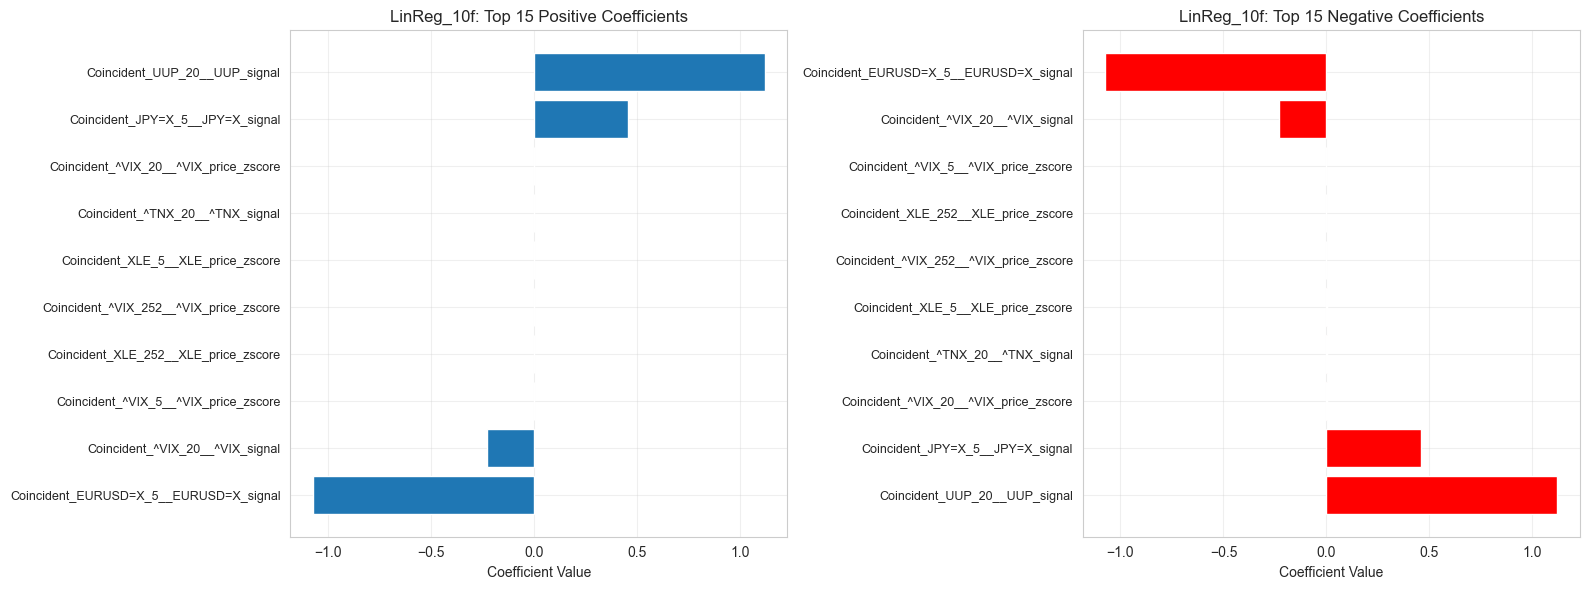


Model: ElasticNet_10f

Intercept: 0.000759

Top 20 Features by Absolute Coefficient:
                               feature  coefficient  abs_coefficient
Coincident_EURUSD=X_5__EURUSD=X_signal         -0.0              0.0
      Coincident_JPY=X_5__JPY=X_signal          0.0              0.0
       Coincident_^VIX_20__^VIX_signal         -0.0              0.0
Coincident_^VIX_252__^VIX_price_zscore         -0.0              0.0
  Coincident_^VIX_5__^VIX_price_zscore         -0.0              0.0
       Coincident_^TNX_20__^TNX_signal          0.0              0.0
         Coincident_UUP_20__UUP_signal          0.0              0.0
 Coincident_^VIX_20__^VIX_price_zscore         -0.0              0.0
    Coincident_XLE_5__XLE_price_zscore          0.0              0.0
  Coincident_XLE_252__XLE_price_zscore          0.0              0.0

Non-zero coefficients: 0/10


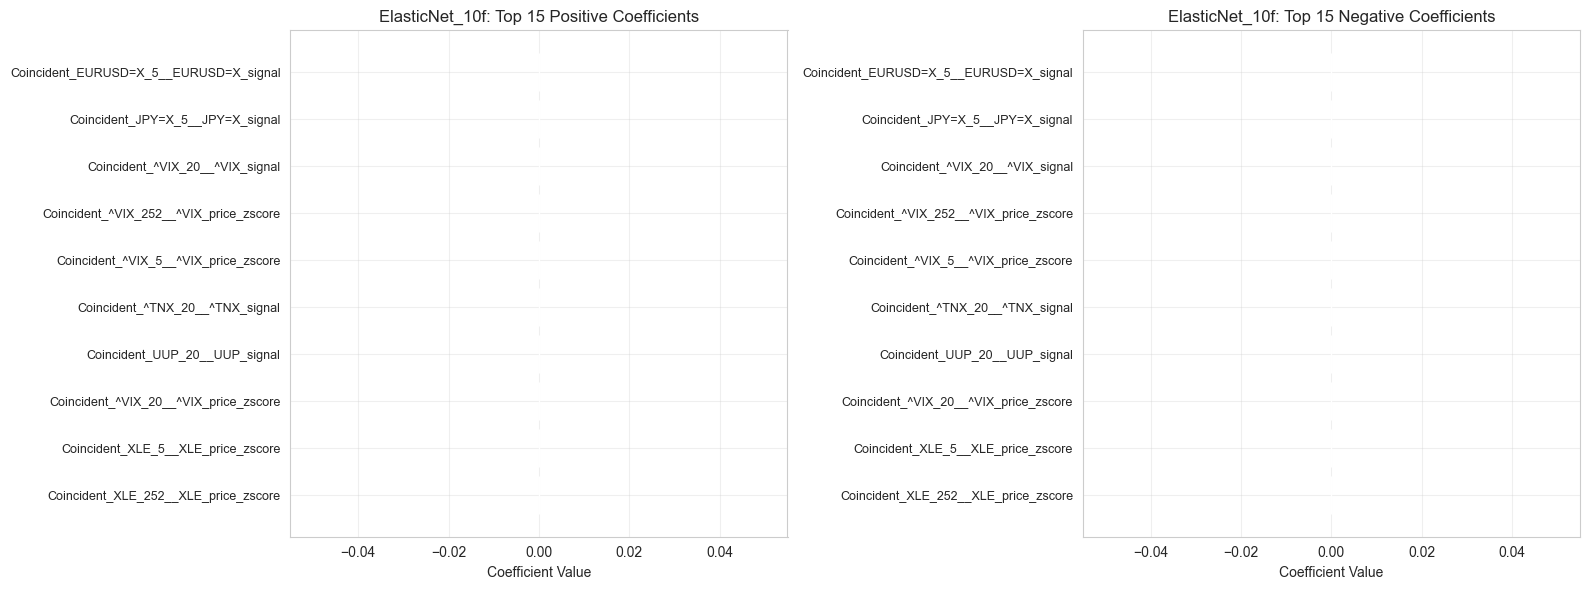


Model: LASSO_10f

Intercept: 0.000759

Top 20 Features by Absolute Coefficient:
                               feature  coefficient  abs_coefficient
Coincident_EURUSD=X_5__EURUSD=X_signal         -0.0              0.0
      Coincident_JPY=X_5__JPY=X_signal          0.0              0.0
       Coincident_^VIX_20__^VIX_signal         -0.0              0.0
Coincident_^VIX_252__^VIX_price_zscore         -0.0              0.0
  Coincident_^VIX_5__^VIX_price_zscore         -0.0              0.0
       Coincident_^TNX_20__^TNX_signal          0.0              0.0
         Coincident_UUP_20__UUP_signal          0.0              0.0
 Coincident_^VIX_20__^VIX_price_zscore         -0.0              0.0
    Coincident_XLE_5__XLE_price_zscore          0.0              0.0
  Coincident_XLE_252__XLE_price_zscore          0.0              0.0

Non-zero coefficients: 0/10


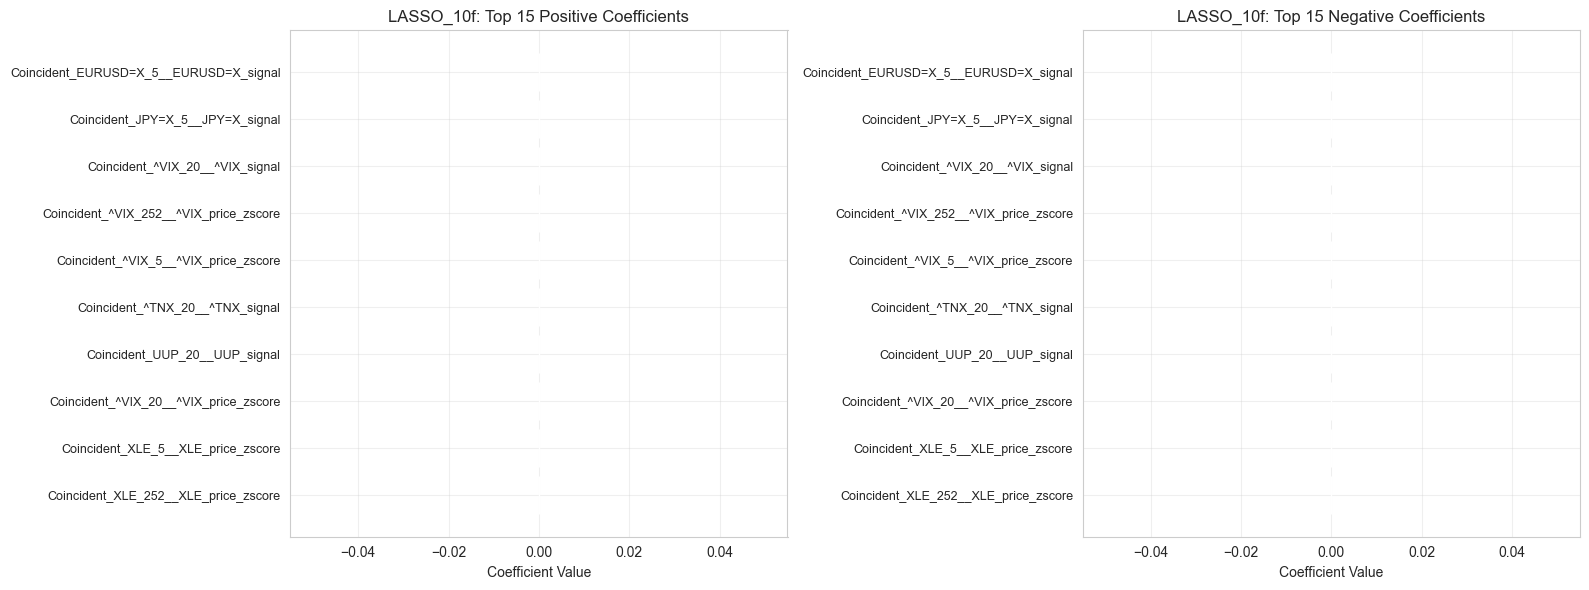

In [26]:
def get_linear_coefficients(strategy, feature_names):
    """Extract coefficients from linear models."""
    model = strategy.model
    
    # For GridSearchCV, get the best estimator
    if hasattr(model, 'best_estimator_'):
        model = model.best_estimator_
    
    if hasattr(model, 'coef_'):
        coef = model.coef_
        intercept = getattr(model, 'intercept_', 0.0)
        
        # Create DataFrame
        coef_df = pd.DataFrame({
            'feature': feature_names,
            'coefficient': coef,
            'abs_coefficient': np.abs(coef)
        })
        coef_df = coef_df.sort_values('abs_coefficient', ascending=False)
        
        return coef_df, intercept
    else:
        return None, None

# Analyze each linear model
linear_model_names = ['LASSO', 'Linear Regression', 'Elastic Net', 'ElasticNet', 'LinearRegression']

for strat in strategies:
    if any(name in strat.name or name in str(type(strat.model)) for name in linear_model_names):
        print(f"\n{'='*70}")
        print(f"Model: {strat.name}")
        print(f"{'='*70}")
        
        coef_df, intercept = get_linear_coefficients(strat, feature_names)
        
        if coef_df is not None:
            print(f"\nIntercept: {intercept:.6f}")
            print(f"\nTop 20 Features by Absolute Coefficient:")
            print(coef_df.head(20).to_string(index=False))
            
            # Count non-zero coefficients (for LASSO/Elastic Net)
            non_zero = (coef_df['coefficient'] != 0).sum()
            print(f"\nNon-zero coefficients: {non_zero}/{len(coef_df)}")
            
            # Plot top coefficients
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
            
            # Top positive coefficients
            top_positive = coef_df.nlargest(15, 'coefficient')
            ax1.barh(range(len(top_positive)), top_positive['coefficient'].values)
            ax1.set_yticks(range(len(top_positive)))
            ax1.set_yticklabels(top_positive['feature'].values, fontsize=9)
            ax1.set_xlabel('Coefficient Value')
            ax1.set_title(f'{strat.name}: Top 15 Positive Coefficients')
            ax1.invert_yaxis()
            ax1.grid(True, alpha=0.3)
            
            # Top negative coefficients
            top_negative = coef_df.nsmallest(15, 'coefficient')
            ax2.barh(range(len(top_negative)), top_negative['coefficient'].values, color='red')
            ax2.set_yticks(range(len(top_negative)))
            ax2.set_yticklabels(top_negative['feature'].values, fontsize=9)
            ax2.set_xlabel('Coefficient Value')
            ax2.set_title(f'{strat.name}: Top 15 Negative Coefficients')
            ax2.invert_yaxis()
            ax2.grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()
        else:
            print("No coefficients found for this model.")

## 5. Analyze Tree-Based Feature Importance

Examine feature importance for Random Forest, Gradient Boosting, XGBoost, etc.


Model: ExtraTrees_10f

Top 20 Features by Importance:
                               feature  importance
      Coincident_JPY=X_5__JPY=X_signal    0.178817
Coincident_EURUSD=X_5__EURUSD=X_signal    0.132798
       Coincident_^VIX_20__^VIX_signal    0.125952
  Coincident_XLE_252__XLE_price_zscore    0.122004
Coincident_^VIX_252__^VIX_price_zscore    0.114919
       Coincident_^TNX_20__^TNX_signal    0.094608
    Coincident_XLE_5__XLE_price_zscore    0.067273
         Coincident_UUP_20__UUP_signal    0.061870
 Coincident_^VIX_20__^VIX_price_zscore    0.051679
  Coincident_^VIX_5__^VIX_price_zscore    0.050079

Features accounting for 80% of importance: 6/10
Features accounting for 90% of importance: 8/10


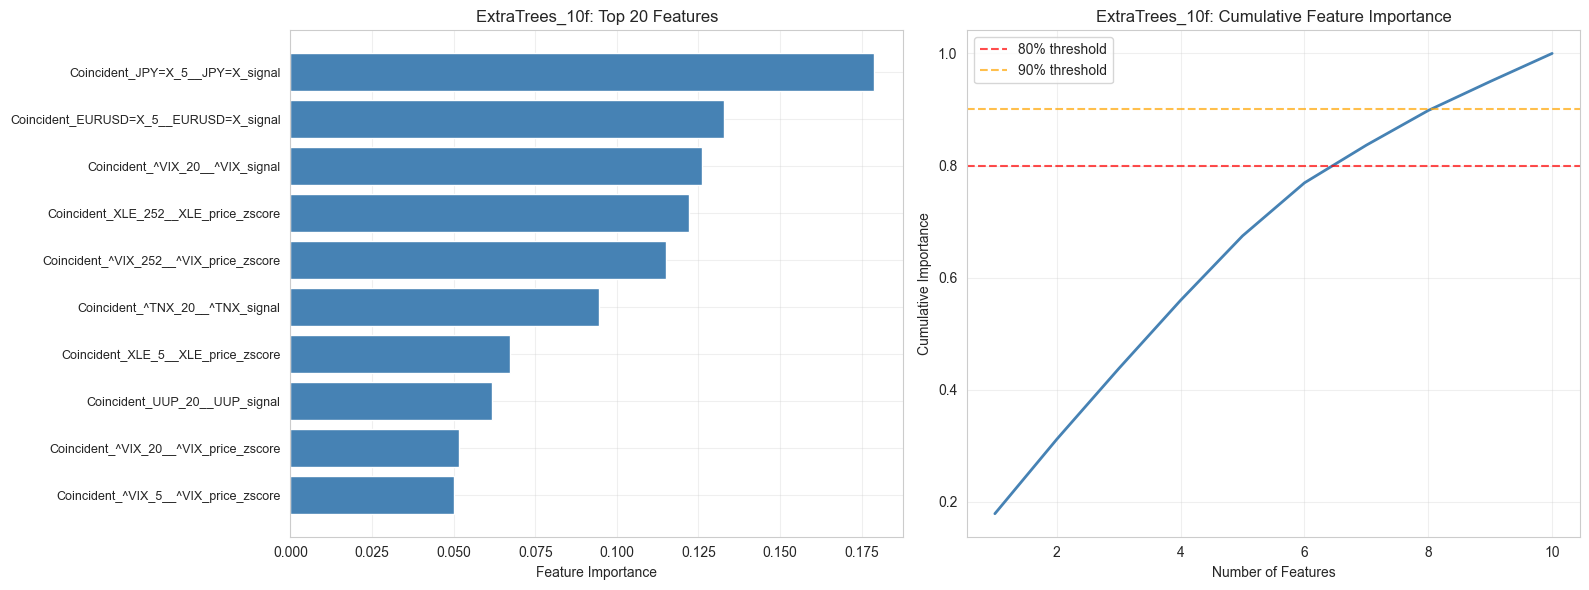


Model: AdaBoost_10f

Top 20 Features by Importance:
                               feature  importance
  Coincident_XLE_252__XLE_price_zscore    0.181661
Coincident_EURUSD=X_5__EURUSD=X_signal    0.172753
       Coincident_^VIX_20__^VIX_signal    0.144621
      Coincident_JPY=X_5__JPY=X_signal    0.131802
Coincident_^VIX_252__^VIX_price_zscore    0.102190
         Coincident_UUP_20__UUP_signal    0.080535
  Coincident_^VIX_5__^VIX_price_zscore    0.078269
       Coincident_^TNX_20__^TNX_signal    0.067146
    Coincident_XLE_5__XLE_price_zscore    0.030091
 Coincident_^VIX_20__^VIX_price_zscore    0.010931

Features accounting for 80% of importance: 5/10
Features accounting for 90% of importance: 7/10


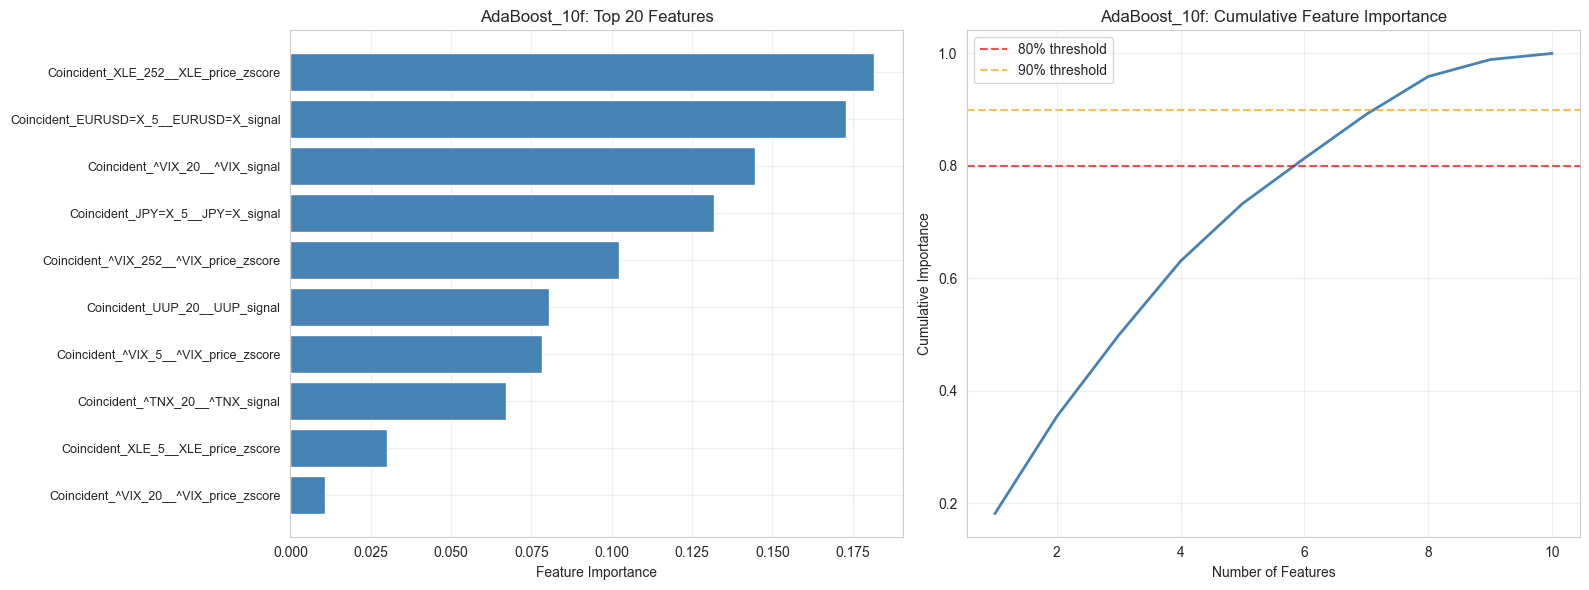

In [27]:
def get_feature_importance(strategy, feature_names):
    """Extract feature importance from tree-based models."""
    model = strategy.model
    
    # For GridSearchCV, get the best estimator
    if hasattr(model, 'best_estimator_'):
        model = model.best_estimator_
    
    if hasattr(model, 'feature_importances_'):
        importance = model.feature_importances_
        
        # Create DataFrame
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': importance
        })
        importance_df = importance_df.sort_values('importance', ascending=False)
        
        return importance_df
    else:
        return None

# Analyze each tree-based model
tree_model_names = ['RandomForest', 'GradientBoosting', 'XGBoost', 'ExtraTrees', 'DecisionTree', 'AdaBoost']

for strat in strategies:
    if any(name in strat.name or name in str(type(strat.model)) for name in tree_model_names):
        print(f"\n{'='*70}")
        print(f"Model: {strat.name}")
        print(f"{'='*70}")
        
        importance_df = get_feature_importance(strat, feature_names)
        
        if importance_df is not None:
            print(f"\nTop 20 Features by Importance:")
            print(importance_df.head(20).to_string(index=False))
            
            # Calculate cumulative importance
            importance_df['cumulative_importance'] = importance_df['importance'].cumsum()
            
            # Find how many features account for 80% and 90% of importance
            n_80 = (importance_df['cumulative_importance'] <= 0.80).sum()
            n_90 = (importance_df['cumulative_importance'] <= 0.90).sum()
            
            print(f"\nFeatures accounting for 80% of importance: {n_80}/{len(importance_df)}")
            print(f"Features accounting for 90% of importance: {n_90}/{len(importance_df)}")
            
            # Plot feature importance
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
            
            # Top 20 features bar chart
            top_20 = importance_df.head(20)
            ax1.barh(range(len(top_20)), top_20['importance'].values, color='steelblue')
            ax1.set_yticks(range(len(top_20)))
            ax1.set_yticklabels(top_20['feature'].values, fontsize=9)
            ax1.set_xlabel('Feature Importance')
            ax1.set_title(f'{strat.name}: Top 20 Features')
            ax1.invert_yaxis()
            ax1.grid(True, alpha=0.3)
            
            # Cumulative importance
            ax2.plot(range(1, len(importance_df) + 1), importance_df['cumulative_importance'].values, 
                    linewidth=2, color='steelblue')
            ax2.axhline(y=0.8, color='red', linestyle='--', label='80% threshold', alpha=0.7)
            ax2.axhline(y=0.9, color='orange', linestyle='--', label='90% threshold', alpha=0.7)
            ax2.set_xlabel('Number of Features')
            ax2.set_ylabel('Cumulative Importance')
            ax2.set_title(f'{strat.name}: Cumulative Feature Importance')
            ax2.legend()
            ax2.grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()
        else:
            print("No feature importance found for this model.")

## Decision Tree: DTree_10f — Trees and Feature Importance

This section locates the strategy named `DTree_10f`, prints its feature importances, and visualizes the decision tree(s). If the strategy is an ensemble, it shows up to 3 trees; otherwise, it shows the single tree.


Model: DTree_10f

Top 20 Features by Importance:
                               feature  importance
  Coincident_XLE_252__XLE_price_zscore    0.432719
       Coincident_^TNX_20__^TNX_signal    0.331646
Coincident_EURUSD=X_5__EURUSD=X_signal    0.151778
      Coincident_JPY=X_5__JPY=X_signal    0.083857
       Coincident_^VIX_20__^VIX_signal    0.000000
Coincident_^VIX_252__^VIX_price_zscore    0.000000
  Coincident_^VIX_5__^VIX_price_zscore    0.000000
         Coincident_UUP_20__UUP_signal    0.000000
 Coincident_^VIX_20__^VIX_price_zscore    0.000000
    Coincident_XLE_5__XLE_price_zscore    0.000000


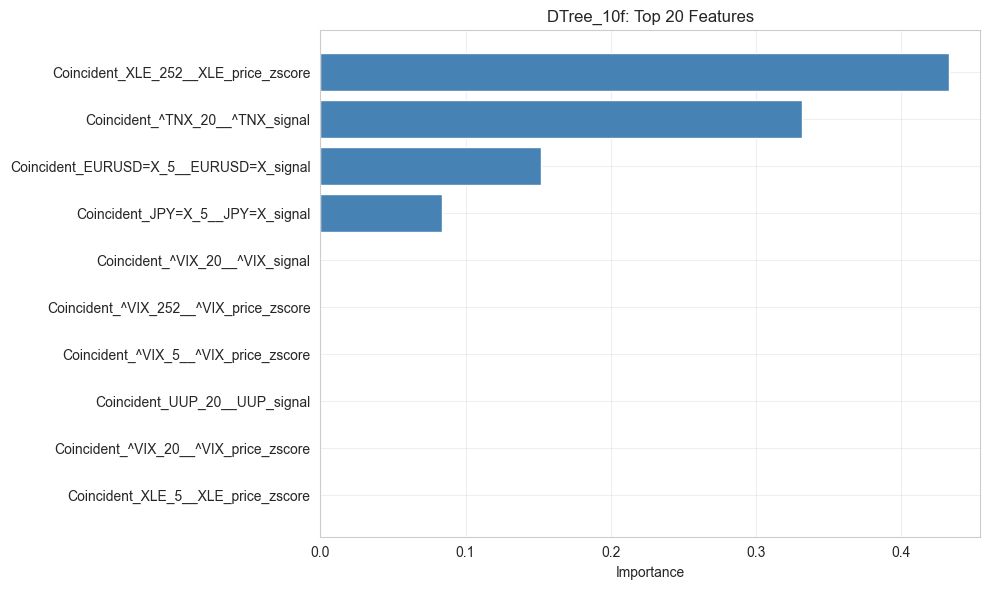


Tree 1 of 1 (text, depth<=4):
|--- Coincident_XLE_252__XLE_price_zscore <= -5.464
|   |--- value: [-0.065]
|--- Coincident_XLE_252__XLE_price_zscore >  -5.464
|   |--- Coincident_EURUSD=X_5__EURUSD=X_signal <= 0.004
|   |   |--- Coincident_^TNX_20__^TNX_signal <= -0.022
|   |   |   |--- Coincident_XLE_252__XLE_price_zscore <= -3.679
|   |   |   |   |--- value: [0.057]
|   |   |   |--- Coincident_XLE_252__XLE_price_zscore >  -3.679
|   |   |   |   |--- value: [0.003]
|   |   |--- Coincident_^TNX_20__^TNX_signal >  -0.022
|   |   |   |--- Coincident_JPY=X_5__JPY=X_signal <= -0.006
|   |   |   |   |--- value: [0.028]
|   |   |   |--- Coincident_JPY=X_5__JPY=X_signal >  -0.006
|   |   |   |   |--- Coincident_JPY=X_5__JPY=X_signal <= 0.004
|   |   |   |   |   |--- value: [0.001]
|   |   |   |   |--- Coincident_JPY=X_5__JPY=X_signal >  0.004
|   |   |   |   |   |--- value: [-0.021]
|   |--- Coincident_EURUSD=X_5__EURUSD=X_signal >  0.004
|   |   |--- Coincident_^TNX_20__^TNX_signal <= -0.02

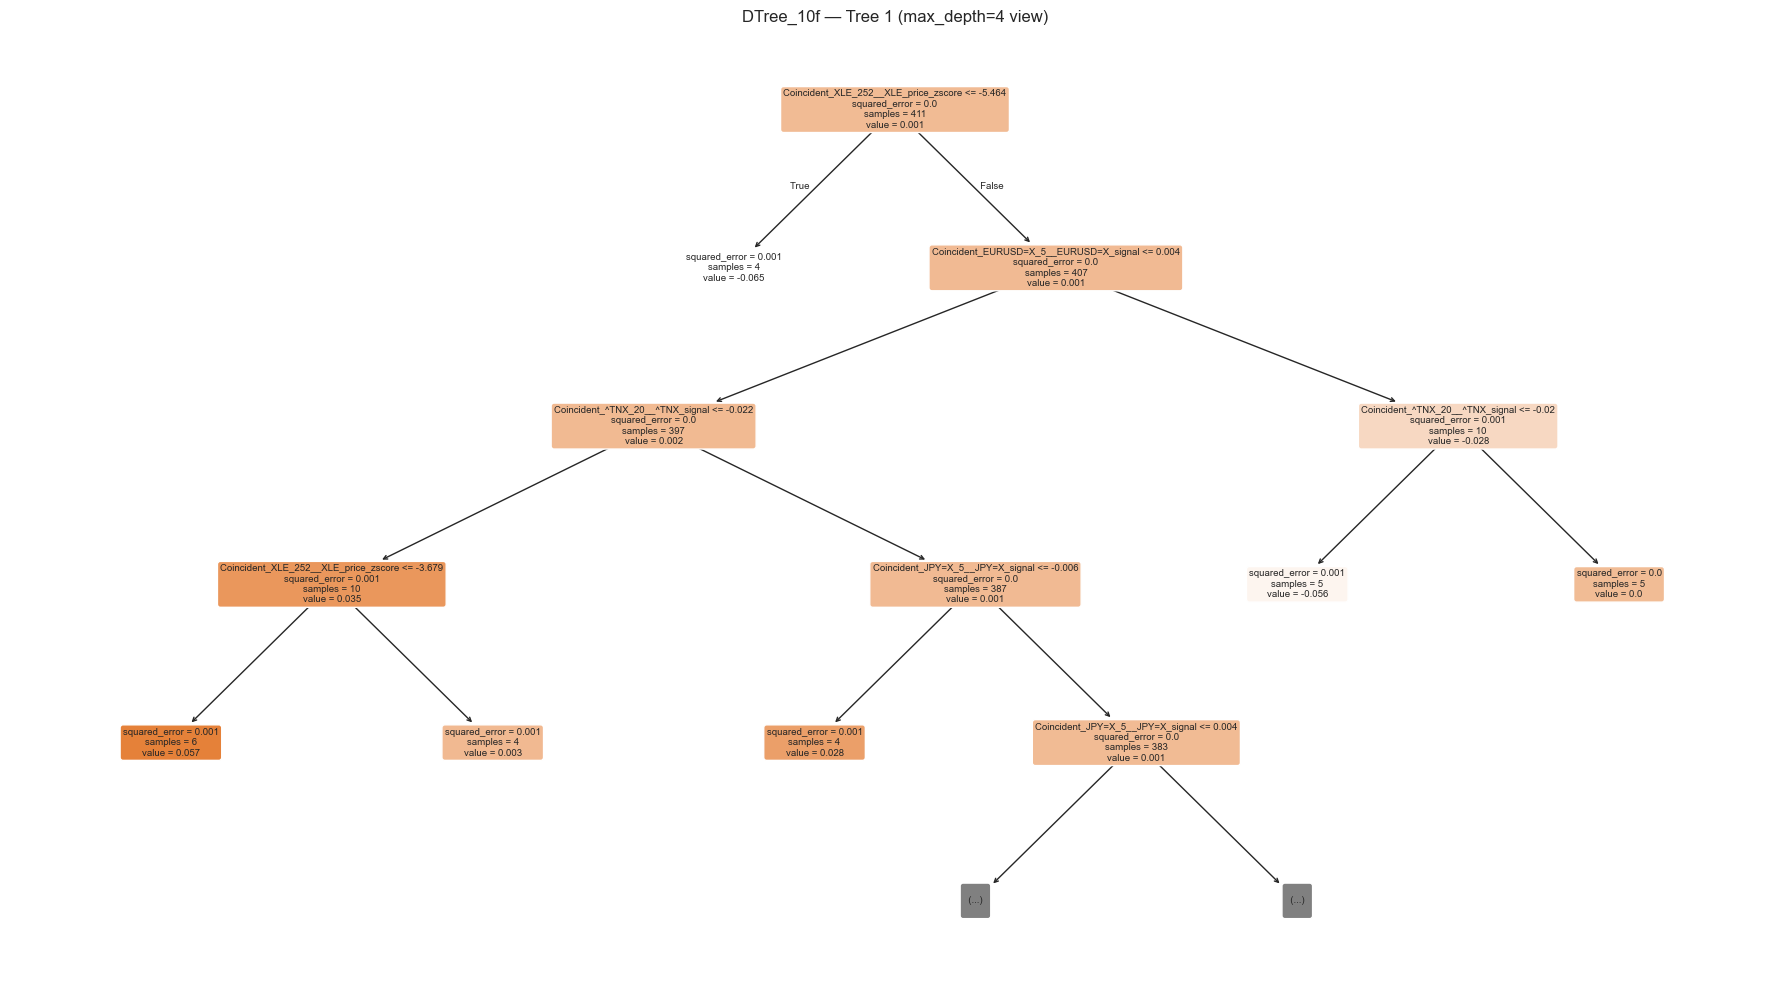

In [28]:
# Show trees and feature importance for DTree_10f
from sklearn import tree
import matplotlib.pyplot as plt

# Target strategy name (partial match)
target_name = 'DTree_10f'

# Sanity check for feature names
if 'feature_names' not in globals() or feature_names is None:
    feature_names = []

# Find matching strategies
dtree_strats = [s for s in strategies if target_name in getattr(s, 'name', '')]

if not dtree_strats:
    print(f"No strategies matching '{target_name}'. Available names:")
    for s in strategies:
        print(f" - {getattr(s, 'name', type(s))}")
else:
    for s in dtree_strats:
        print("\n" + "="*70)
        print(f"Model: {s.name}")
        print("="*70)

        model = s.model
        if hasattr(model, 'best_estimator_') and model.best_estimator_ is not None:
            model = model.best_estimator_

        # Feature importance
        importance_df = get_feature_importance(s, feature_names)
        if importance_df is not None and not importance_df.empty:
            print("\nTop 20 Features by Importance:")
            print(importance_df.head(20).to_string(index=False))

            # Barh plot of top features
            top = importance_df.head(20).iloc[::-1]
            fig, ax = plt.subplots(figsize=(10, 6))
            ax.barh(top['feature'], top['importance'], color='steelblue')
            ax.set_xlabel('Importance')
            ax.set_title(f'{s.name}: Top 20 Features')
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
        else:
            print("No feature_importances_ available or empty for this model.")

        # Prepare estimators list (handle single tree or ensembles)
        if hasattr(model, 'estimators_') and isinstance(model.estimators_, (list, tuple)) and len(model.estimators_) > 0:
            estimators = list(model.estimators_)
        else:
            estimators = [model]

        max_to_show = min(3, len(estimators))
        for idx, est in enumerate(estimators[:max_to_show], start=1):
            # Pick safe feature names (ensure correct length if available)
            names_for_export = None
            names_for_plot = None
            try:
                n_in = getattr(est, 'n_features_in_', None)
                if feature_names and n_in is not None and len(feature_names) == n_in:
                    names_for_export = feature_names
                    names_for_plot = feature_names
            except Exception:
                pass

            # Export text view
            print(f"\nTree {idx} of {len(estimators)} (text, depth<=4):")
            try:
                txt = tree.export_text(est, feature_names=names_for_export, max_depth=4, decimals=3)
                print(txt)
            except Exception as e:
                print(f"(Could not export text view: {e})")

            # Plot tree
            try:
                plt.figure(figsize=(18, 10))
                tree.plot_tree(
                    est,
                    feature_names=names_for_plot,
                    filled=True,
                    rounded=True,
                    max_depth=4,
                    impurity=True,
                )
                plt.title(f"{s.name} — Tree {idx} (max_depth=4 view)")
                plt.tight_layout()
                plt.show()
            except Exception as e:
                print(f"(Could not plot tree: {e})")


## 6. Compare Feature Importance Across Models

Compare which features are consistently important across different models.


FEATURE IMPORTANCE ACROSS ALL MODELS

Top 20 Features (averaged across all models):
                                        mean_importance  std_importance
feature                                                                
Coincident_XLE_252__XLE_price_zscore           0.811866        0.348800
Coincident_EURUSD=X_5__EURUSD=X_signal         0.624068        0.241906
Coincident_JPY=X_5__JPY=X_signal               0.509711        0.266609
Coincident_^TNX_20__^TNX_signal                0.482702        0.252354
Coincident_^VIX_20__^VIX_signal                0.396112        0.293766
Coincident_^VIX_252__^VIX_price_zscore         0.345926        0.317641
Coincident_UUP_20__UUP_signal                  0.327218        0.324271
Coincident_^VIX_5__^VIX_price_zscore           0.148583        0.151204
Coincident_XLE_5__XLE_price_zscore             0.136414        0.128150
Coincident_^VIX_20__^VIX_price_zscore          0.109619        0.108347


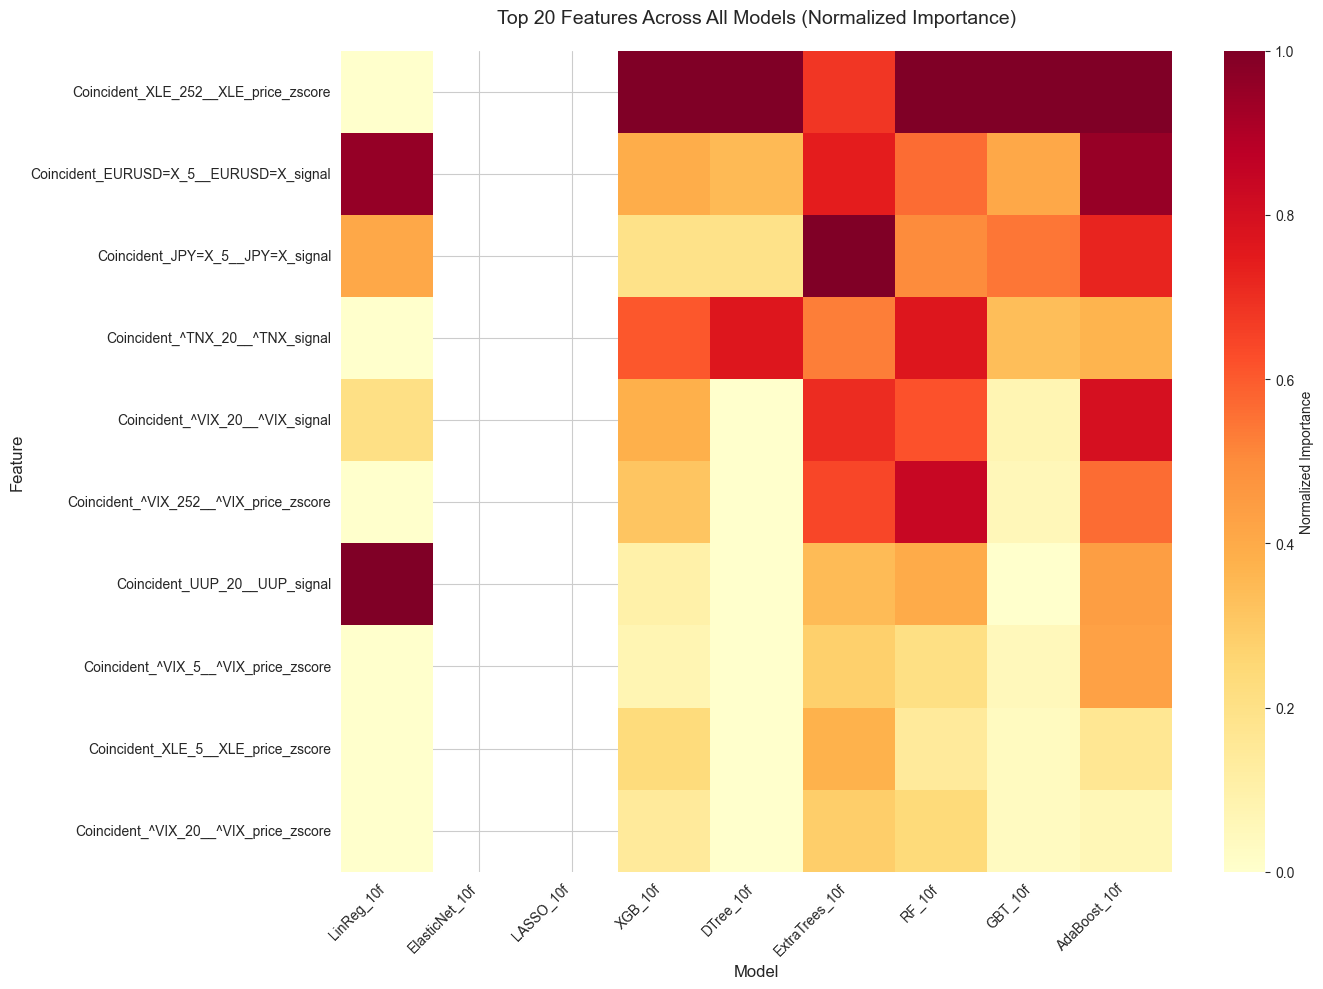

In [29]:
# Collect all feature rankings
all_rankings = {}

for strat in strategies:
    # Try tree-based importance first
    importance_df = get_feature_importance(strat, feature_names)
    if importance_df is not None:
        all_rankings[strat.name] = importance_df.set_index('feature')['importance']
    else:
        # Try linear coefficients
        coef_df, _ = get_linear_coefficients(strat, feature_names)
        if coef_df is not None:
            all_rankings[strat.name] = coef_df.set_index('feature')['abs_coefficient']

if all_rankings:
    # Create combined DataFrame
    rankings_df = pd.DataFrame(all_rankings)
    
    # Normalize each column to 0-1 range for fair comparison
    rankings_normalized = rankings_df.div(rankings_df.max(axis=0), axis=1)
    
    # Calculate average importance across all models
    rankings_normalized['mean_importance'] = rankings_normalized.mean(axis=1)
    rankings_normalized['std_importance'] = rankings_normalized.std(axis=1)
    
    # Sort by mean importance
    rankings_sorted = rankings_normalized.sort_values('mean_importance', ascending=False)
    
    print("\n" + "="*70)
    print("FEATURE IMPORTANCE ACROSS ALL MODELS")
    print("="*70)
    print("\nTop 20 Features (averaged across all models):")
    print(rankings_sorted[['mean_importance', 'std_importance']].head(20).to_string())
    
    # Plot heatmap of top features across models
    top_features = rankings_sorted.head(20).index
    heatmap_data = rankings_normalized.loc[top_features, rankings_df.columns]
    
    plt.figure(figsize=(14, 10))
    sns.heatmap(heatmap_data, cmap='YlOrRd', annot=False, cbar_kws={'label': 'Normalized Importance'})
    plt.title('Top 20 Features Across All Models (Normalized Importance)', fontsize=14, pad=20)
    plt.xlabel('Model', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No feature rankings available.")

## 7. Model Performance Comparison


MODEL PERFORMANCE METRICS
         Model  Train MSE  Test MSE  Overfit Ratio
ElasticNet_10f   0.000301  0.000118       0.391075
     LASSO_10f   0.000301  0.000118       0.391075
  AdaBoost_10f   0.000147  0.000119       0.807646
       XGB_10f   0.000166  0.000122       0.733638
       GBT_10f   0.000186  0.000123       0.658403
       KNN_10f   0.000266  0.000130       0.488897
ExtraTrees_10f   0.000075  0.000132       1.753374
        RF_10f   0.000156  0.000136       0.870838
    LinReg_10f   0.000279  0.000139       0.498516
     DTree_10f   0.000161  0.000163       1.010029


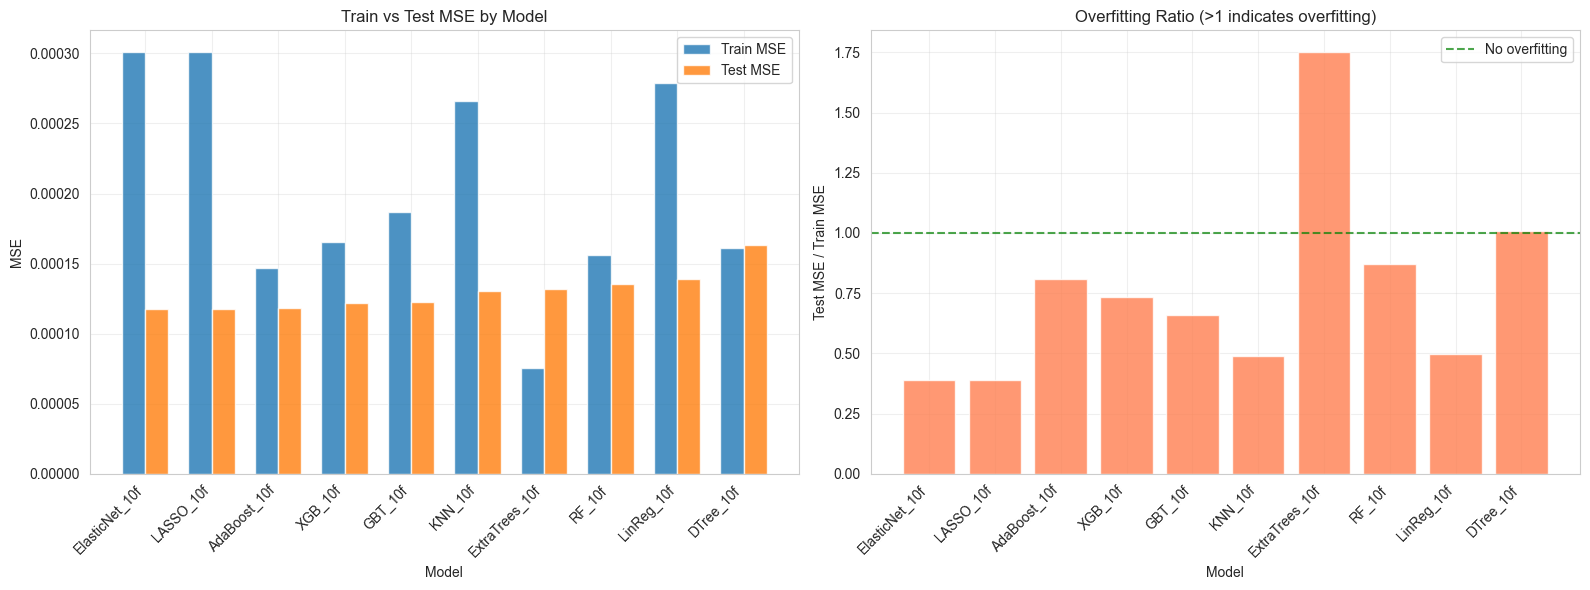

In [30]:
# Extract performance metrics
performance_data = []

for strat in strategies:
    perf = {
        'Model': strat.name,
        'Train MSE': strat.train_mse if hasattr(strat, 'train_mse') else None,
        'Test MSE': strat.test_mse if hasattr(strat, 'test_mse') else None,
    }
    
    # Calculate overfitting ratio
    if perf['Train MSE'] and perf['Test MSE'] and perf['Train MSE'] > 0:
        perf['Overfit Ratio'] = perf['Test MSE'] / perf['Train MSE']
    else:
        perf['Overfit Ratio'] = None
    
    performance_data.append(perf)

perf_df = pd.DataFrame(performance_data).sort_values('Test MSE')

print("\n" + "="*70)
print("MODEL PERFORMANCE METRICS")
print("="*70)
print(perf_df.to_string(index=False))

# Plot performance comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# MSE comparison
x = range(len(perf_df))
width = 0.35

ax1.bar([i - width/2 for i in x], perf_df['Train MSE'], width, label='Train MSE', alpha=0.8)
ax1.bar([i + width/2 for i in x], perf_df['Test MSE'], width, label='Test MSE', alpha=0.8)
ax1.set_xlabel('Model')
ax1.set_ylabel('MSE')
ax1.set_title('Train vs Test MSE by Model')
ax1.set_xticks(x)
ax1.set_xticklabels(perf_df['Model'], rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Overfitting ratio
valid_overfit = perf_df[perf_df['Overfit Ratio'].notna()]
ax2.bar(range(len(valid_overfit)), valid_overfit['Overfit Ratio'], color='coral', alpha=0.8)
ax2.axhline(y=1.0, color='green', linestyle='--', label='No overfitting', alpha=0.7)
ax2.set_xlabel('Model')
ax2.set_ylabel('Test MSE / Train MSE')
ax2.set_title('Overfitting Ratio (>1 indicates overfitting)')
ax2.set_xticks(range(len(valid_overfit)))
ax2.set_xticklabels(valid_overfit['Model'], rotation=45, ha='right')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Export Feature Rankings to CSV